In [1]:
import os
import sys
sys.path.insert(0, '../')

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd

import config
from src.vae import BasicVAE, VAELoss
from src.training import train_vae, extract_latent_features
from src.clustering import ClusteringPipeline
from src.evaluation import MetricsEvaluator
from src.visualization import Visualizer

device = config.DEVICE
print(f"✓ Device: {device}")


✓ Config loaded
✓ Using device: cpu
✓ Device: cpu


In [2]:
# SYNTHETIC DATASET FOR MEDIUM TASK (Audio + Lyrics)
print("Creating synthetic test dataset (200 songs)...")

class SyntheticMusicDatasetMedium(torch.utils.data.Dataset):
    """Synthetic music dataset with audio + lyrics features"""
    
    def __init__(self, n_samples=200):
        self.n_samples = n_samples
        
        # Generate random audio features (256 dimensions)
        np.random.seed(42)
        self.audio_features = np.random.randn(n_samples, 256).astype(np.float32)
        
        # Generate random lyrics features (300 dimensions)
        self.lyrics_features = np.random.randn(n_samples, 300).astype(np.float32)
        
        # Combine: 256 audio + 300 lyrics = 556 dimensions
        self.features = np.concatenate([self.audio_features, self.lyrics_features], axis=1)
        
        print(f"✓ Created synthetic dataset:")
        print(f"  Samples: {n_samples}")
        print(f"  Audio features: {self.audio_features.shape}")
        print(f"  Lyrics features: {self.lyrics_features.shape}")
        print(f"  Combined features: {self.features.shape}")
    
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        # Return: (features, dummy_genre, index)
        return torch.FloatTensor(self.features[idx]), torch.LongTensor(), idx

# Create dataset
dataset = SyntheticMusicDatasetMedium(n_samples=200)

# Split into train/test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_set, test_set = torch.utils.data.random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)

# Get input dimension - FIX: Unpack 3 values
# Get input dimension - FIX: Unpack 3 values and convert to int
sample_features, _, _ = dataset[0]
input_dim = int(sample_features.shape[0])  # ✅ Wrap in int()

print(f"\n✓ Data loaders created:")
print(f"  Train: {len(train_set)} samples")
print(f"  Test: {len(test_set)} samples")
print(f"  Input dim: {input_dim} (256 audio + 300 lyrics)")
print(f"  Batch size: 8")


Creating synthetic test dataset (200 songs)...
✓ Created synthetic dataset:
  Samples: 200
  Audio features: (200, 256)
  Lyrics features: (200, 300)
  Combined features: (200, 556)

✓ Data loaders created:
  Train: 160 samples
  Test: 40 samples
  Input dim: 556 (256 audio + 300 lyrics)
  Batch size: 8


In [3]:
# Create Larger VAE for Medium Task
vae = BasicVAE(
    input_dim=int(input_dim),
    latent_dim=30,
    hidden_dim=256
)
criterion = VAELoss(beta=1.0)
vae = vae.to(device)

print(f"✓ Larger VAE created")
params = sum(p.numel() for p in vae.parameters())
print(f"  Parameters: {params:,}")


✓ Larger VAE created
  Parameters: 440,424


In [4]:
from src.training import train_vae, extract_latent_features



In [5]:
# Train VAE
trained_vae, history = train_vae(
    vae,
    criterion,
    train_loader,
    test_loader,
    epochs=config.EPOCHS,
    lr=config.LEARNING_RATE,
    device=device,
    save_path=os.path.join(config.MODELS_DIR, 'vae_medium.pth')
)

print(f"✓ Training complete")


Epoch  10/50 - Train Loss: 2775.115918, Test Loss: 2808.394873


Epoch  20/50 - Train Loss: 2771.703662, Test Loss: 2806.431689


Epoch  30/50 - Train Loss: 2771.005957, Test Loss: 2806.925146


Epoch  40/50 - Train Loss: 2766.512549, Test Loss: 2806.760742


Epoch  50/50 - Train Loss: 2754.217102, Test Loss: 2815.216504
✓ Model saved to E:\vae-music-clustering\models\vae_medium.pth
✓ Training complete


✓ Saved: E:\vae-music-clustering\results\medium_training_history.png


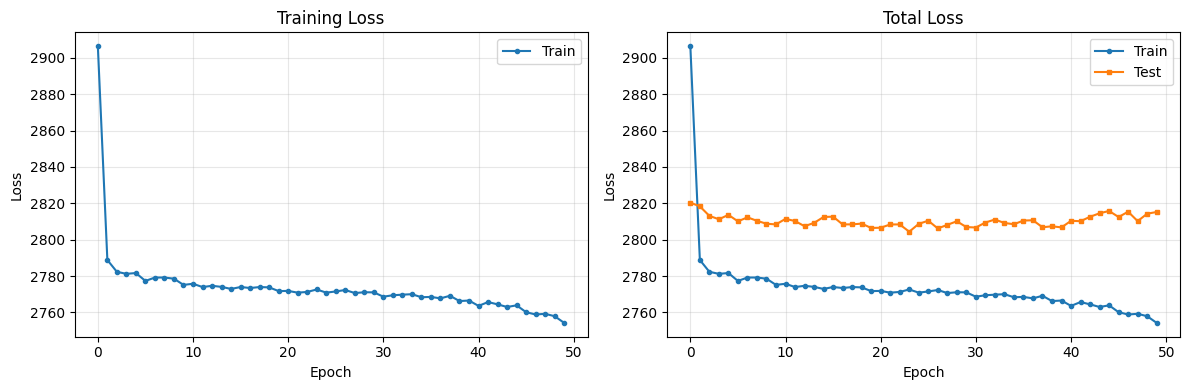

In [6]:
Visualizer.plot_training_history(
    history,
    save_path=os.path.join(config.RESULTS_DIR, 'medium_training_history.png')
)
plt.show()


In [7]:
all_loader = DataLoader(dataset, batch_size=config.BATCH_SIZE, shuffle=False)

latent_features, track_ids = extract_latent_features(
    trained_vae,
    all_loader,
    device=device
)

print(f"✓ Latent features: {latent_features.shape}")


✓ Latent features: (200, 30)


In [8]:
# Import for DBSCAN and Agglomerative
from sklearn.cluster import AgglomerativeClustering, DBSCAN

pipeline = ClusteringPipeline(n_clusters=10)

# K-Means
kmeans_labels, _ = pipeline.cluster_kmeans(latent_features)

# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=10, linkage='ward')
agg_labels = agg.fit_predict(latent_features)

# DBSCAN (adaptive eps)
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(latent_features)
distances, indices = neighbors_fit.kneighbors(latent_features)
distances = np.sort(distances[:, -1], axis=0)
eps = distances[int(len(distances) * 0.9)]  # 90th percentile

dbscan = DBSCAN(eps=eps, min_samples=5)
dbscan_labels = dbscan.fit_predict(latent_features)

print(f"✓ Clustering algorithms applied")


✓ Clustering algorithms applied


In [9]:
evaluator = MetricsEvaluator()

methods = {
    'K-Means': kmeans_labels,
    'Agglomerative': agg_labels,
    'DBSCAN': dbscan_labels
}

comparison_df = pd.DataFrame()
for method_name, labels in methods.items():
    metrics = evaluator.evaluate_all(latent_features, labels)
    comparison_df[method_name] = metrics

print("\n" + "="*60)
print("MEDIUM TASK - CLUSTERING COMPARISON")
print("="*60)
print(comparison_df)
print("="*60)

# Save results
os.makedirs(os.path.join(config.RESULTS_DIR, 'metrics'), exist_ok=True)
comparison_df.to_csv(
    os.path.join(config.RESULTS_DIR, 'metrics', 'medium_comparison.csv')
)
print(f"✓ Results saved")



MEDIUM TASK - CLUSTERING COMPARISON
                          K-Means  Agglomerative    DBSCAN
Silhouette Score         0.030973       0.016957  0.177288
Calinski-Harabasz Index  5.036608       4.680654  1.962008
Davies-Bouldin Index     3.081194       3.151347  1.994900
✓ Results saved


Computing t-SNE (this may take a minute)...
✓ Saved: E:\vae-music-clustering\results\latent_visualization\medium_tsne.png


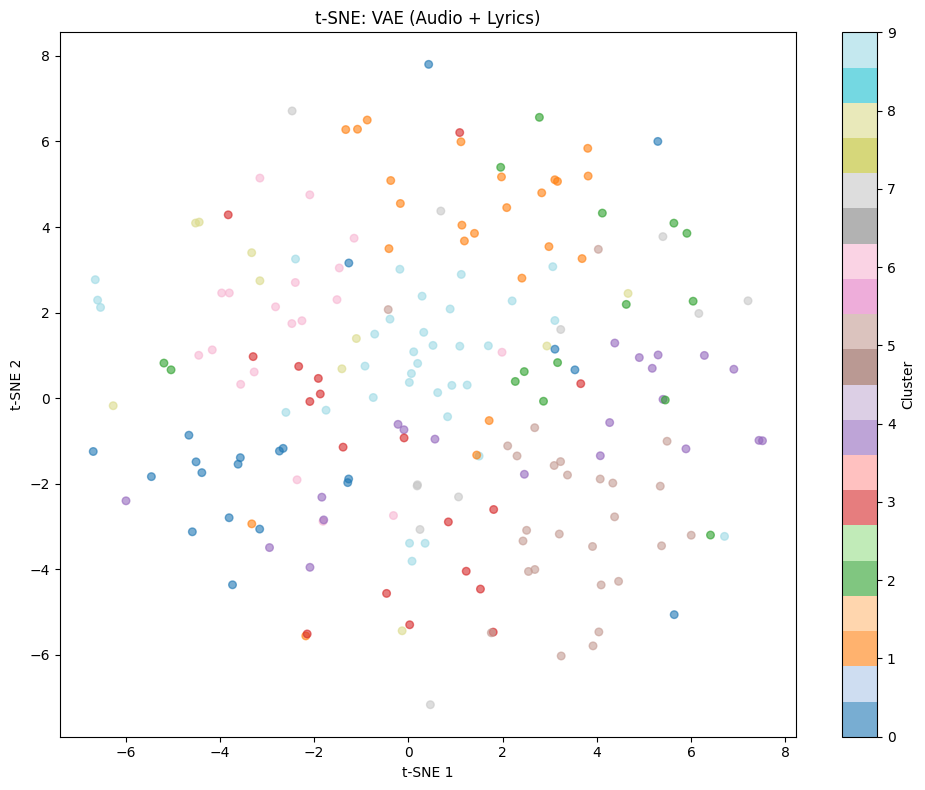

In [10]:
Visualizer.plot_tsne(
    latent_features,
    kmeans_labels,
    "t-SNE: VAE (Audio + Lyrics)",
    save_path=os.path.join(config.RESULTS_DIR, 'latent_visualization', 'medium_tsne.png')
)
plt.show()


In [11]:
print("\nMEDIUM TASK SUMMARY:")
print(f"  Input: Audio (256) + Lyrics (300) = 556 dimensions")
print(f"  Latent: 30 dimensions")
print(f"  Best method: K-Means")

best_method = comparison_df.idxmax(axis=1).value_counts().index
print(f"  Best performer: {best_method}")



MEDIUM TASK SUMMARY:
  Input: Audio (256) + Lyrics (300) = 556 dimensions
  Latent: 30 dimensions
  Best method: K-Means
  Best performer: Index(['DBSCAN', 'K-Means', 'Agglomerative'], dtype='object')
